# Learned Closure: Training a Neural Viscosity Model Through a PDE Solver (PyTorch)

In this tutorial, you will learn how to:

1. **Build a Tesseract** that wraps a single-timestep differentiable PDE solver (a 1D Burgers' equation solver) and exposes a vector-Jacobian product.
2. **Use [Tesseract-Torch](https://github.com/pasteurlabs/tesseract-torch)** to call the served solver as a native PyTorch autograd layer via `apply_tesseract`, so gradients flow through the container automatically.
3. **Train a neural network closure end-to-end** through the containerized solver, differentiating through the entire time-stepping loop.
4. **Compare the learned closure against baselines** (a pure physics model and a pure ML model).

We will replace the viscosity model of a Burgers' equation solver, normally a hand-tuned constant, with a small neural network, and train it so that it recovers the true (unknown) viscosity profile from solution data alone.

This is a small end-to-end example of embedding a learned closure into a solver with Tesseract. The closure is called once per solver step, which is the right structure when the physics genuinely needs a per-step update. It is deliberately kept simple so the moving parts are easy to follow; the *What's next* section at the end points to the tricks real closures usually need.

## Context

Closure modeling is a recurring problem across computational science: a simulation resolves the large scales but needs a model for the unresolved physics, such as a turbulence closure, a sub-grid scheme, or a constitutive law. These closures are often hand-tuned or empirical, and a natural idea is to *learn* them from data instead ([Duraisamy, Iaccarino & Xiao, 2019](https://doi.org/10.1146/annurev-fluid-010518-040547)). The catch is that a closure only makes sense *inside* the solver: to train it well, gradients have to flow from the simulation output, through the solver, and back into the network ([Um et al., 2020](https://arxiv.org/abs/2007.00016); [Shankar et al., 2023](https://doi.org/10.1088/2632-2153/acb19c)).

This is hard in practice because the solver is usually not a 30-line function you can `import` into your training script. It is often a heavyweight simulator with its own runtime, dependencies, and adjoint: a Fortran/C++ CFD code, a legacy in-house solver, or something differentiated by [Enzyme](https://enzyme.mit.edu/) at the LLVM IR level.

**Tesseract is most useful for that hard case:** a big, expensive simulator with a gnarly toolchain (a specific compiler, MPI, a licensed library, a non-Python runtime, a hand-written adjoint) that you want to hide behind a clean differentiable interface. The Burgers' solver used here is the opposite: a few lines of NumPy/Torch, cheap to run, and trivially `import`-able, so on its own it needs no container at all and the HTTP round-trip dominates its runtime. We use it precisely *because* it is cheap, so the whole demo runs in a few minutes. The composition pattern below is identical either way; only the overhead changes.

With Tesseracts, we wrap the solver in a container that exposes a clean differentiable interface, and call it over HTTP as a single layer inside an otherwise ordinary PyTorch training loop. The neural network lives in native PyTorch; the solver lives in a Docker image. [Tesseract-Torch](https://github.com/pasteurlabs/tesseract-torch) registers the served solver as a PyTorch autograd custom function, so `loss.backward()` dispatches a vector-Jacobian product (VJP) call back through the solver automatically, the analogue of what [Tesseract-JAX](https://github.com/pasteurlabs/tesseract-jax) does for JAX in the other demos in this series.

### The components

- **`burgers_solver`** (containerized Tesseract): a single-timestep Burgers' equation solver. Takes the current velocity field `u` and a viscosity field `nu`, returns the velocity field after one explicit Euler step, a pure physics component with the interface $(u, \nu, dt) \to u_\text{next}$. It exposes a VJP, so it slots into PyTorch autograd like any other layer, even though it runs in a separate container.
- **`ViscosityNet`** (`torch.nn.Module`): a small MLP that maps local flow features $(u, \partial u/\partial x, x)$ to a viscosity field $\nu$. An ordinary network, trained with a standard optimizer, in this process.

At each timestep the outer loop calls the network directly to predict $\nu$, then calls the solver via `apply_tesseract` to advance one step (shown in full in Step 4).

To learn more about building and running Tesseracts, please refer to the [Tesseract documentation](https://docs.pasteurlabs.ai/projects/tesseract-core/latest/).

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tesseract_torch import apply_tesseract

from tesseract_core import Tesseract

torch.set_default_dtype(torch.float64)

# Workload size. Every solver call is an HTTP round-trip to the container, so
# the defaults are modest to keep the demo (and CI) to a few minutes.
# Set FULL_RUN=1 for the publication-quality run used to produce the figures.
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"

# Time step. The spatially-varying viscosity only becomes identifiable once
# diffusion has acted appreciably over the rollout, so we use a dt large enough
# for the closure to actually "feel" the viscosity profile (well within the
# explicit-diffusion CFL limit nu*dt/dx^2 < 0.5; here nu_max*dt/dx^2 ≈ 0.40).
# Too small a dt and every viscosity profile fits the data equally well: the
# closure can't recover the shape no matter how long it trains. Using a larger
# dt also lets us keep the rollout short. The closure is called once per step
# and we backprop through the whole chain, so fewer steps means a cheaper,
# better-behaved gradient. A real, longer rollout would reach for gradient
# checkpointing here (see the "What's next" section).
DT = 5e-4
LR = 5e-3

if FULL_RUN:
    N_TRAIN, N_TEST = 8, 4
    N_STEPS = 40
    N_EPOCHS = 300
    DIRECT_EPOCHS = 300
else:
    # Small but enough to recover the viscosity hump and beat the constant
    # baseline.
    N_TRAIN, N_TEST = 3, 2
    N_STEPS = 20
    N_EPOCHS = 100
    DIRECT_EPOCHS = 100

print(
    f"FULL_RUN={FULL_RUN}: {N_TRAIN} train / {N_TEST} test ICs, "
    f"{N_STEPS} steps, {N_EPOCHS} epochs, dt={DT}"
)

# Grid setup (must match the solver)
N = 128
DX = 1.0 / (N - 1)
X = torch.linspace(0.0, 1.0, N)

FULL_RUN=False: 3 train / 2 test ICs, 20 steps, 100 epochs, dt=0.0005


## Step 1: Build and serve the solver Tesseract

We build the solver into a Docker image with `tesseract build`, then serve it in a container and call it over HTTP, the same way you would deploy a real simulator. The training loop below never imports the solver's code; it only ever talks to the running container.

First, build the image (this can take a few minutes the first time):

In [2]:
%%bash
tesseract build burgers_solver/

 [i] Building image ...
⠋ Processing
 [i] Built image sha256:270b9738ccf8, ['burgers-solver:0.1.0', 'burgers-solver:latest']


["burgers-solver:0.1.0", "burgers-solver:latest"]


Now load the built image and start a server container. `serve()` launches the container; we tear it down at the end of the notebook to free resources.

In [3]:
solver_tess = Tesseract.from_image("burgers-solver")
solver_tess.serve()
print(f"Solver endpoints: {solver_tess.available_endpoints}")

Solver endpoints: ['apply', 'jacobian', 'jacobian_vector_product', 'vector_jacobian_product', 'health', 'abstract_eval', 'test']


## Step 2: The ground truth --- Burgers' equation with spatially-varying viscosity

We generate training data from a Burgers' equation with a **known but non-trivial** viscosity profile:

$$\nu_{\text{true}}(x) = \nu_0 \left(1 + A \sin(\pi x)\right)$$

This represents a spatially-varying material property, analogous to a turbulence closure, constitutive law, or sub-grid model that varies across the domain. The neural closure's job is to recover this profile from solution data alone.

The reference solutions come from the **same served solver**, called forward-only (no gradients); there is no second copy of the physics anywhere in this notebook.

Training set: 3 initial conditions -> solutions
Test set:     2 initial conditions -> solutions
Grid: 128 points, dt=0.0005, 20 steps


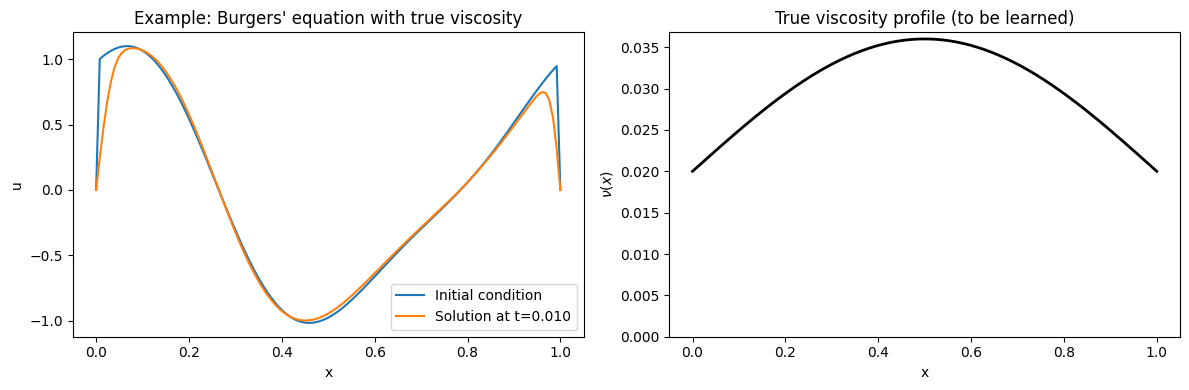

In [4]:
# True viscosity profile
NU_0 = 0.02
A = 0.8
nu_true = NU_0 * (1.0 + A * torch.sin(np.pi * X))


def burgers_reference(u0, nu_field, dt, n_steps):
    """Reference solution with a prescribed viscosity field (no neural network).

    Calls the served solver Tesseract forward-only via `.apply()`. This is just
    data generation, so it stays outside autograd. `.apply()` returns decoded
    NumPy arrays, which we wrap back into tensors.
    """
    u = u0.clone()
    for _ in range(n_steps):
        out = solver_tess.apply({"u": u, "nu": nu_field, "dt": dt})
        # .apply() returns a (possibly read-only) NumPy array decoded from JSON;
        # copy into a fresh tensor so PyTorch is happy.
        u = torch.tensor(np.asarray(out["u_next"]))
    return u


def make_ic(seed):
    """Random smooth initial condition: sum of low-frequency sinusoids."""
    rng = torch.Generator().manual_seed(seed)
    a1 = 0.5 + 0.5 * torch.rand(1, generator=rng).item()
    a2 = 0.3 * torch.rand(1, generator=rng).item()
    phase = torch.rand(1, generator=rng).item() * np.pi
    u0 = a1 * torch.sin(2 * np.pi * X + phase) + a2 * torch.sin(4 * np.pi * X)
    u0[0] = 0.0
    u0[-1] = 0.0
    return u0


train_ics = torch.stack([make_ic(i) for i in range(N_TRAIN)])
test_ics = torch.stack([make_ic(N_TRAIN + i) for i in range(N_TEST)])

with torch.no_grad():
    train_targets = torch.stack(
        [burgers_reference(ic, nu_true, DT, N_STEPS) for ic in train_ics]
    )
    test_targets = torch.stack(
        [burgers_reference(ic, nu_true, DT, N_STEPS) for ic in test_ics]
    )

print(f"Training set: {N_TRAIN} initial conditions -> solutions")
print(f"Test set:     {N_TEST} initial conditions -> solutions")
print(f"Grid: {N} points, dt={DT}, {N_STEPS} steps")

# Visualize one example
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(X.numpy(), train_ics[0].numpy(), label="Initial condition")
axes[0].plot(
    X.numpy(), train_targets[0].numpy(), label=f"Solution at t={DT * N_STEPS:.3f}"
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[0].legend()
axes[0].set_title("Example: Burgers' equation with true viscosity")

axes[1].plot(X.numpy(), nu_true.numpy(), "k-", linewidth=2)
axes[1].set_xlabel("x")
axes[1].set_ylabel(r"$\nu(x)$")
axes[1].set_title("True viscosity profile (to be learned)")
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## Step 3: The neural closure --- a plain PyTorch module

The closure is an ordinary `torch.nn.Module`: a small MLP with 2 hidden layers of 32 units. It maps the local flow features $(u, \partial u/\partial x, x)$ at each grid point to a viscosity value. There is nothing Tesseract-specific about it; it is the network the closure researcher brings, trained with a standard optimizer, entirely in this process.

A sigmoid keeps the predicted viscosity in a physically reasonable range $[0, \nu_{\max}]$, which also prevents CFL violations in the explicit solver.

In [5]:
class ViscosityNet(nn.Module):
    """MLP closure: local flow features (u, du/dx, x) -> viscosity nu."""

    def __init__(self, hidden_dim=32, nu_max=0.05):
        super().__init__()
        self.nu_max = nu_max
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, u, dudx, x):
        features = torch.stack([u, dudx, x], dim=-1)  # (N, 3)
        out = self.net(features)[:, 0]  # (N,)
        return self.nu_max * torch.sigmoid(out)


torch.manual_seed(1)
closure = ViscosityNet()
n_params = sum(p.numel() for p in closure.parameters())
print(f"Closure parameters: {n_params}")

# Sanity check: the untrained closure produces sensible viscosities
with torch.no_grad():
    dudx0 = torch.gradient(train_ics[0], spacing=(DX,))[0]
    nu0 = closure(train_ics[0], dudx0, X)
print(f"Initial viscosity range: [{float(nu0.min()):.4f}, {float(nu0.max()):.4f}]")

Closure parameters: 1217
Initial viscosity range: [0.0204, 0.0310]


## Step 4: End-to-end training through the containerized solver

The training loss is:

$$\mathcal{L}(\theta) = \frac{1}{M} \sum_{i=1}^{M} \left\| u_{\text{solver}}(u_0^{(i)}; \nu_\theta) - u_{\text{data}}^{(i)} \right\|^2$$

where $\nu_\theta$ is the neural viscosity closure with parameters $\theta$, and $u_{\text{solver}}$ runs the full Burgers' equation with $\nu_\theta$ called at every timestep.

The time-stepping loop calls the network directly and the solver via `apply_tesseract`:

```python
for each timestep:
    nu = closure(u, dudx, x)                              # plain torch
    u  = apply_tesseract(solver, {u, nu, dt})["u_next"]   # HTTP call to container
```

`loss.backward()` differentiates through the entire loop: through every timestep, through a VJP HTTP request to the container at each step, and into the network weights, all automatically.

In [6]:
def solve_with_closure(u0, closure, dt, n_steps):
    """Run the full time-stepping loop, calling the served solver each step.

    The closure is plain in-process PyTorch; the solver is the containerized
    differentiable layer, reached over HTTP. In production this same loop would
    drive a Fortran solver with an adjoint, with only the served image changing.
    """
    u = u0
    for _step in range(n_steps):
        dudx = torch.zeros_like(u)
        dudx[1:-1] = (u[2:] - u[:-2]) / (2 * DX)

        nu = closure(u, dudx, X)  # closure: predict viscosity (native torch)

        # Solver: one explicit Euler step, executed in the container
        solver_out = apply_tesseract(solver_tess, {"u": u, "nu": nu, "dt": dt})
        u = solver_out["u_next"]
    return u


def loss_batch(closure, ics, targets):
    """Mean MSE over a batch of initial conditions."""
    preds = torch.stack(
        [solve_with_closure(ics[i], closure, DT, N_STEPS) for i in range(ics.shape[0])]
    )
    return torch.mean((preds - targets) ** 2)


# Verify the forward pass + gradient flow
print("Testing forward pass + gradient...")
l0 = loss_batch(closure, train_ics, train_targets)
l0.backward()
grad_norm = torch.sqrt(
    sum(p.grad.pow(2).sum() for p in closure.parameters() if p.grad is not None)
)
print(f"  Initial loss: {float(l0.detach()):.6e}")
print(f"  Gradient norm: {float(grad_norm):.6e}")
print("  Gradients flow: loss -> solver VJP (HTTP) -> network weights.")
closure.zero_grad()

Testing forward pass + gradient...
  Initial loss: 1.283973e-04
  Gradient norm: 1.046508e-03
  Gradients flow: loss -> solver VJP (HTTP) -> network weights.


### Gradient validation against finite differences

Correctness check: the AD gradient (loss → solver VJP over HTTP → network) matches finite differences to high precision.

In [7]:
# Finite difference check on a single weight element of the first layer.
ics_sub = train_ics[:2]
tgt_sub = train_targets[:2]

# AD gradient
closure.zero_grad()
loss_val = loss_batch(closure, ics_sub, tgt_sub)
loss_val.backward()

w = closure.net[0].weight.data  # first Linear layer (raw tensor, no autograd)
idx = (0, 0)
ad = float(closure.net[0].weight.grad[idx])

# Finite difference
eps = 1e-5
orig = w[idx].item()
with torch.no_grad():
    w[idx] = orig + eps
    l_plus = float(loss_batch(closure, ics_sub, tgt_sub))
    w[idx] = orig - eps
    l_minus = float(loss_batch(closure, ics_sub, tgt_sub))
    w[idx] = orig  # restore

fd = (l_plus - l_minus) / (2 * eps)
rel_err = abs(ad - fd) / (abs(fd) + 1e-30)
print(f"{'AD':>14s} {'FD':>14s} {'Rel. Error':>12s}")
print(f"{ad:14.6e} {fd:14.6e} {rel_err:12.2e}")
closure.zero_grad()

            AD             FD   Rel. Error
 -6.627976e-07  -6.627976e-07     6.68e-10


### Training loop

In [8]:
# Re-initialize for a clean training run
torch.manual_seed(1)
closure = ViscosityNet()
optimizer = torch.optim.Adam(closure.parameters(), lr=LR)

train_losses = []
test_losses = []

print("Training neural closure through the solver...")
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
    train_loss = loss_batch(closure, train_ics, train_targets)
    train_loss.backward()
    optimizer.step()
    train_losses.append(float(train_loss.detach()))

    if epoch % 10 == 0 or epoch == N_EPOCHS - 1:
        with torch.no_grad():
            test_loss = float(loss_batch(closure, test_ics, test_targets))
        test_losses.append((epoch, test_loss))
        print(
            f"  Epoch {epoch:4d}: train loss = {train_losses[-1]:.4e}, "
            f"test loss = {test_loss:.4e}"
        )

print(f"\nFinal train loss: {train_losses[-1]:.4e}")
print(f"Final test loss:  {test_losses[-1][1]:.4e}")

Training neural closure through the solver...
  Epoch    0: train loss = 1.2840e-04, test loss = 8.8252e-06
  Epoch   10: train loss = 1.1664e-05, test loss = 5.9784e-06
  Epoch   20: train loss = 1.1159e-05, test loss = 6.0776e-06
  Epoch   30: train loss = 9.1783e-06, test loss = 4.2518e-06
  Epoch   40: train loss = 6.9523e-06, test loss = 3.9642e-06
  Epoch   50: train loss = 5.6923e-06, test loss = 3.4751e-06
  Epoch   60: train loss = 4.7374e-06, test loss = 2.9877e-06
  Epoch   70: train loss = 4.0577e-06, test loss = 2.7151e-06
  Epoch   80: train loss = 3.6290e-06, test loss = 2.7027e-06
  Epoch   90: train loss = 3.3559e-06, test loss = 2.6873e-06
  Epoch   99: train loss = 3.1723e-06, test loss = 2.7432e-06

Final train loss: 3.1723e-06
Final test loss:  2.7432e-06


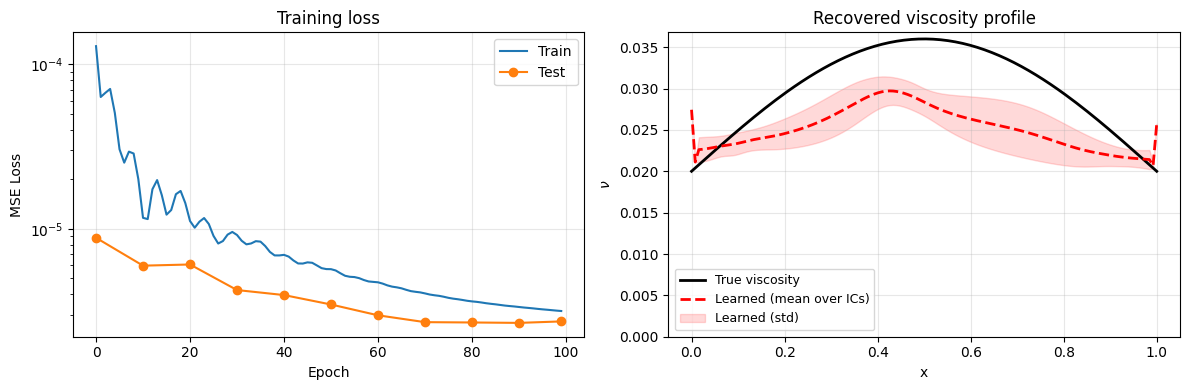

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(train_losses, label="Train")
test_epochs, test_vals = zip(*test_losses, strict=False)
axes[0].semilogy(test_epochs, test_vals, "o-", label="Test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Compare learned viscosity to true viscosity, averaged over training ICs.
nu_samples = []
with torch.no_grad():
    for ic in train_ics:
        dudx = torch.zeros_like(ic)
        dudx[1:-1] = (ic[2:] - ic[:-2]) / (2 * DX)
        nu_samples.append(closure(ic, dudx, X))
nu_samples = torch.stack(nu_samples)
nu_mean = nu_samples.mean(dim=0)
nu_std = nu_samples.std(dim=0)

x_np = X.numpy()
axes[1].plot(x_np, nu_true.numpy(), "k-", linewidth=2, label="True viscosity")
axes[1].plot(x_np, nu_mean.numpy(), "r--", linewidth=2, label="Learned (mean over ICs)")
axes[1].fill_between(
    x_np,
    (nu_mean - nu_std).numpy(),
    (nu_mean + nu_std).numpy(),
    color="r",
    alpha=0.15,
    label="Learned (std)",
)
axes[1].set_xlabel("x")
axes[1].set_ylabel(r"$\nu$")
axes[1].set_title("Recovered viscosity profile")
axes[1].legend(fontsize=9)
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5: Baselines

We compare three approaches:

| Model | Description |
|---|---|
| **Constant viscosity** | Burgers' solver with $\nu = \nu_0$ (the standard "wrong" closure) |
| **Direct ML** | MLP trained to map $u_0 \to u_\text{final}$ directly, no physics |
| **Learned closure** | Neural $\nu(u, \partial u/\partial x, x)$ trained through the solver (this demo) |

The closure here is **not trained to convergence**: the CI defaults keep the run to a few minutes, so the recovered viscosity profile is approximate. As a result the learned closure decisively beats the pure-ML baseline but only edges out the constant-viscosity baseline, which stays competitive at this short budget. Set `FULL_RUN=1` for the longer run that sharpens the profile and widens that gap. The point of this demo is the composition pattern, not a state-of-the-art closure.

In [10]:
# --- Baseline 1: Constant (wrong) viscosity ---
nu_const = NU_0 * torch.ones(N)
with torch.no_grad():
    const_preds_test = torch.stack(
        [burgers_reference(ic, nu_const, DT, N_STEPS) for ic in test_ics]
    )
const_mse = float(torch.mean((const_preds_test - test_targets) ** 2))
print(f"Constant viscosity test MSE: {const_mse:.4e}")


# --- Baseline 2: Direct ML (MLP mapping u0 -> u_final, no physics) ---
class DirectNet(nn.Module):
    """Pure ML: maps the whole field u0 directly to u_final."""

    def __init__(self, n=N, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 64),
            nn.Tanh(),
            nn.Linear(64, n),
        )

    def forward(self, u0):
        return self.net(u0)


def direct_loss(model, ics, targets):
    preds = model(ics)
    return torch.mean((preds - targets) ** 2)


torch.manual_seed(2)
direct = DirectNet()
direct_opt = torch.optim.Adam(direct.parameters(), lr=1e-3)

print("\nTraining direct ML baseline...")
for epoch in range(DIRECT_EPOCHS):
    direct_opt.zero_grad()
    dl = direct_loss(direct, train_ics, train_targets)
    dl.backward()
    direct_opt.step()
    if epoch % 20 == 0:
        with torch.no_grad():
            test_dl = float(direct_loss(direct, test_ics, test_targets))
        print(
            f"  Epoch {epoch:4d}: train = {float(dl.detach()):.4e}, test = {test_dl:.4e}"
        )

with torch.no_grad():
    direct_test_mse = float(direct_loss(direct, test_ics, test_targets))
print(f"\nDirect ML test MSE: {direct_test_mse:.4e}")

# --- Learned closure (already trained above) ---
with torch.no_grad():
    learned_test_mse = float(loss_batch(closure, test_ics, test_targets))
print(f"Learned closure test MSE: {learned_test_mse:.4e}")

print(f"\n{'Model':<25s} {'Test MSE':>12s}")
print("-" * 40)
print(f"{'Constant viscosity':<25s} {const_mse:12.4e}")
print(f"{'Direct ML':<25s} {direct_test_mse:12.4e}")
print(f"{'Learned closure':<25s} {learned_test_mse:12.4e}")

Constant viscosity test MSE: 6.1354e-06

Training direct ML baseline...
  Epoch    0: train = 3.3670e-01, test = 2.0239e-01
  Epoch   20: train = 3.7105e-02, test = 1.1341e-01
  Epoch   40: train = 4.0102e-03, test = 7.2236e-02
  Epoch   60: train = 1.2106e-03, test = 7.4998e-02
  Epoch   80: train = 6.3123e-04, test = 7.7559e-02

Direct ML test MSE: 7.8228e-02
Learned closure test MSE: 2.7432e-06

Model                         Test MSE
----------------------------------------
Constant viscosity          6.1354e-06
Direct ML                   7.8228e-02
Learned closure             2.7432e-06


## Step 6: Solution comparison on test data

For unseen initial conditions, we compare the three models' predictions against the ground truth.

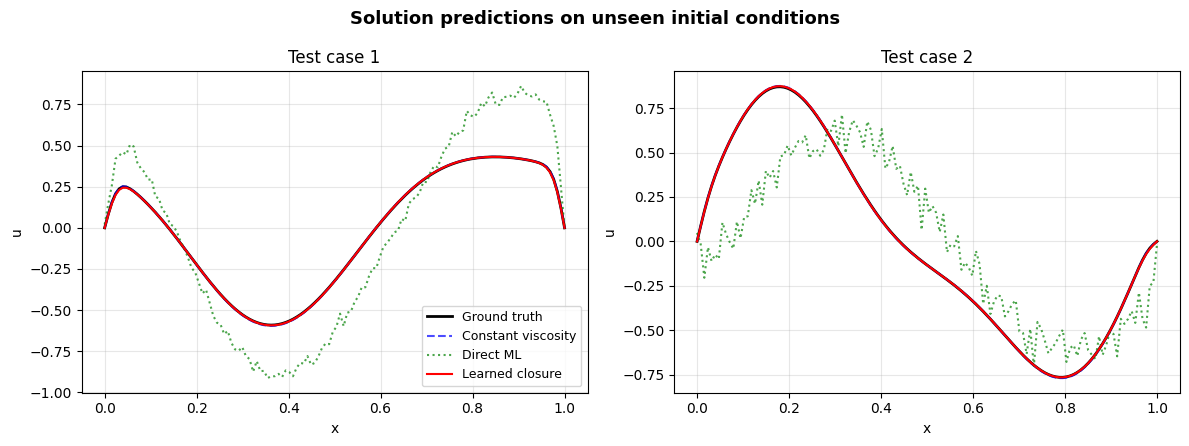

In [11]:
n_show = min(4, N_TEST)
ncols = 2 if n_show > 1 else 1
nrows = (n_show + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)

with torch.no_grad():
    direct_preds = direct(test_ics)
    for idx in range(n_show):
        ax = axes[idx // ncols][idx % ncols]
        ic = test_ics[idx]
        target = test_targets[idx]

        const_pred = burgers_reference(ic, nu_const, DT, N_STEPS)
        direct_pred = direct_preds[idx]
        learned_pred = solve_with_closure(ic, closure, DT, N_STEPS)

        ax.plot(x_np, target.numpy(), "k-", linewidth=2, label="Ground truth")
        ax.plot(
            x_np,
            const_pred.numpy(),
            "b--",
            linewidth=1.5,
            alpha=0.7,
            label="Constant viscosity",
        )
        ax.plot(
            x_np, direct_pred.numpy(), "g:", linewidth=1.5, alpha=0.7, label="Direct ML"
        )
        ax.plot(
            x_np, learned_pred.numpy(), "r-", linewidth=1.5, label="Learned closure"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("u")
        ax.set_title(f"Test case {idx + 1}")
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=9)

plt.suptitle(
    "Solution predictions on unseen initial conditions", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## Tear down the solver

Stop the solver container to free resources.

In [12]:
# Tear down Tesseract after use to prevent resource leaks
solver_tess.teardown()

## Takeaways

In this tutorial, we trained a neural viscosity closure end-to-end through a containerized Burgers' equation solver. Here are the key points:

1. **Containerized solver, native ML.** The solver runs in a Docker container served as a Tesseract; the closure is a plain in-process `torch.nn.Module`. The two compose in an outer time-stepping loop, with `apply_tesseract` bridging the container boundary at each step.

2. **End-to-end gradients through the container.** Because Tesseract-Torch registers the served solver as a PyTorch autograd function, `loss.backward()` dispatches the solver's VJP over HTTP and flows the gradient into the network, with no hand-coded plumbing. We validated these gradients against finite differences.

3. **Physics structure helps.** Even with the short CI training budget, the learned closure beats the pure-ML baseline by orders of magnitude and edges out the constant-viscosity baseline, recovering the shape of the true viscosity profile from solution data alone. Training longer with `FULL_RUN=1` widens the margin over the constant baseline.

4. **Composability across a container boundary.** The closure (plain torch) and the solver (a different image exposing the same $(u, \nu, dt) \to u_\text{next}$ contract) can be swapped independently. The training loop is identical regardless of what language the solver is written in or how its adjoint is produced.

5. **Mind the overhead.** Every solver call here is an HTTP round-trip, and a single explicit Euler step is cheap, so this demo is overhead-bound. Tesseract pays off when the solver step is expensive relative to the round-trip (a real CFD/FEM step, a remote or cross-language solver), or when you can space closure updates out over several steps. See the [performance guide](../concepts/performance.md) for the overhead breakdown and rules of thumb.

### What's next

This demo is the basic recipe. Real-world closures usually need more than a vanilla MLP trained with Adam through a single-step solver. Here are the directions to explore from here:

- **Wrap a legacy solver.** Replace the Burgers' Tesseract with a Fortran/C++ solver that exposes an adjoint (for example via [Enzyme](https://enzyme.mit.edu/)). The closure training loop above works unchanged; only the image name changes.
- **Train smarter.** For small closures with a least-squares loss, a Gauss--Newton or L-BFGS solve on the point-wise residual Jacobian (forward-mode AD) can converge far faster than Adam and more readily unlearn spurious feature dependence.
- **Get more data for free.** Chain the solver to emit several snapshots per simulation and train on all of them: extra supervision at no extra simulation cost, and a natural reason to chunk the rollout into shorter segments.
- **Go to longer rollouts.** When the closure is called over many steps, use gradient checkpointing to keep memory bounded, and batch/vmap solver calls to amortize HTTP overhead (batching multiple initial conditions per request).
- **Tackle a real closure.** Swap the Burgers' equation for a turbulence model, a climate sub-grid scheme, or a materials constitutive law.
- **Explore other demos.** See the [CFD optimization](cfd-optimization.ipynb), [FEM shape optimization](fem-shape-optimization.ipynb), and [data assimilation](data-assimilation.ipynb) demos for the JAX side of the same composition pattern.

Built something with these? We'd love to see it. Share your closure on the [Tesseract Community Forum](https://si-tesseract.discourse.group/), and tell us where Tesseract's overhead or UX got in your way so we can improve it.